# Goal:
Train different tokenizers from scratch and use a constant transformer (one we built or used) 

#### Not to do:
do not load gpt2-tokenizer, bert tokenizer etc because they are already pre-trained. This way we would compare pre-trained tokenizers and not evaluate tokenization strategies. 

### What we should do:
- load a dataset OR we can load several datasets (english/russian/japanese/romanian)
- for each tokenization strategy train tokenizer from scratch:
    -- BPE using tokenizers or SentencePiece
    -- Unigram using SentencePiece
    -- byte-level tokenizers via tokenizers.ByteLevelBPETokenizer or raw byte encoding
    -- custom strategy
- build small identical model for each tokenizer
    -- small transformer instead of an RNN (embedding -> transformer blocks (2-4 layers) -> LM head )
    -- each model is reinitialised from scratch for each tokenizer
- train model for a fixed number of steps or compute cost - maybe for the throughput of bits or characters
- compare results based on
    -- perplexity / validation loss (generalization)
    -- efficiency (training speed, tokens/sec, ect)
    -- tokenization-independent metrics (byte-per-character, embedding parameter size)

Perplexity - how well  model predicts the next token = e^(cross-entropy loss). To measure the perplexity across different tokenizers with different strategies, we need to normalize them (because different size of tokens etc.). To do that ,we use the BPC (bits per character) = loss(in nats)/ ln(2) * tokens/characters.

## Import text dataset

Our goal is to have a text dataset of two languages. The proportion of lanugaes should eb 50/50. Morevoer, we think it is interesting to investigate how a tokenizer and a model using it would perform on different alphabets. For that purpose, we decided to choose the latin and cyrilic alphabets. As for languages, it is English (that we all speak and can thus evaluate) and Russian (that one of the group members knows). This small research will show us what happens when combining two alphabets that are smewhat similar (not like latin and kanji for example), but still have different charaters.   
We are taking 5 million characters per each language - this is our dataset limit. 

In [56]:
from datasets import load_dataset


def load_wikipedia_text(language, target_chars):
    dataset = load_dataset(
        "wikimedia/wikipedia",
        f"20231101.{language}",
        split="train",
        # trust_remote_code=True,
        # uncomment this line to save to $BLACKHOLE in HPC
        # cache_dir="/dtu/blackhole/00/223200"
    )

    texts = []
    chars_collected = 0

    for row in dataset:
        article = row["text"]
        article_len = len(article)

        if chars_collected + article_len <= target_chars:
            texts.append(article)
            chars_collected += article_len
        else:
            # Only take the portion we need to reach the target
            remaining = target_chars - chars_collected
            texts.append(article[:remaining])
            chars_collected += remaining
            break

    print(f"{language}: collected {chars_collected:,} characters from {len(texts):,} articles")
    return texts


# https://arxiv.org/pdf/2203.15556#page=24.27  in this paper they set the ratio for optimal language model training to 20 tokens per trainable parameter

trainable_params = 2_168_064  # number of trainable parameters in our model when using vocab size of 16000

TARGET = trainable_params * 20  # target number of characters to load; we fix this for all other experiments

text_en = load_wikipedia_text("en", TARGET // 2)
text_ru = load_wikipedia_text("ru", TARGET // 2)
text = text_en + text_ru

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/41 [00:00<?, ?it/s]

en: collected 21,680,640 characters from 941 articles


Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/21 [00:00<?, ?it/s]

ru: collected 21,680,640 characters from 1,131 articles


# Training different Tokenizers

## BPE tokenizer

In [57]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
# from tokenizers.pre_tokenizers import Whitespace
from tokenizers.pre_tokenizers import BertPreTokenizer
from tokenizers.trainers import BpeTrainer
from pathlib import Path
import os

def train_bpe_tokenizer(texts, vocab_size=16000, save_path="tokenizers/bpe_tokenizer.json"):
    """
    Train a BPE tokenizer from scratch on the provided text dataset.

    Params:
        texts (List[str]): A list of raw text documents (e.g., from Wikipedia)
        vocab_size (int): Desired vocabulary size
        save_path (str): Path to save the trained tokenizer (.json format)

    Returns:
        tokenizer (Tokenizer): A trained BPE tokenizer instance
    """
    print("Training BPE tokenizer...")

    # 1. Create the tokenizer object
    tokenizer = Tokenizer(BPE())

    # 2. Define a pre-tokenizer
    # tokenizer.pre_tokenizer = Whitespace() ## the pre-tokenizer splits the text into chunks - words or basic units. In this case, it splits them into words. This will give us the initial tokens from which the BPE will learn and produce final tokens
    tokenizer.pre_tokenizer = BertPreTokenizer()

    # 3. Trainer config
    trainer = BpeTrainer(
        vocab_size=vocab_size,
        min_frequency=2,
        special_tokens=["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"], ## these are just special tokens
    )

    # 4. Train the tokenizer using an iterator over dataset texts
    tokenizer.train_from_iterator(texts, trainer)

    # 5. Save tokenizer to file
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    tokenizer.save(str(save_path))

    print(f"BPE tokenizer trained and saved to {save_path}")
    return tokenizer

bpe_tokenizer_path = "tokenizers/bpe_tokenizer.json"

if os.path.exists(bpe_tokenizer_path):
    print("Loading existing tokenizer")
    bpe_tokenizer = Tokenizer.from_file(bpe_tokenizer_path)
else:
    bpe_tokenizer = train_bpe_tokenizer(text, vocab_size=16000, save_path=bpe_tokenizer_path)
## one thing to consider is the vocab size. smaller vocab - longer tokens, faster training, but then we have longer sequences and harder learning
## 16k-32k is ususally used
## 50-100k shorter tokens sequences with wasteful memory, more parameters and diminishing returns


Loading existing tokenizer


## Unigram Tokenizer

## Custom Tokenizer

### Set Final Tokenizer:

In [58]:
tokenizer = bpe_tokenizer
# tokenizer = ...
# tokenizer = ...

### Helper Class for Handling Tokenizers


In [ ]:
from typing import List, Iterable
import torch
from torch.utils.data import Dataset, DataLoader

## converts long list of token ids into many small overlapping training samples for next-token language model
## produces sliding windows of seq_len size
## input x are token sequences
## outputs y are the same sequences shifted by one position - meaning predict the next token
## this way, the model learns - given the sequence, what comes next?
class NextTokenDataset(Dataset):
    def __init__(self, token_ids: List[int], seq_len: int, pad_id: int):
        self.ids = token_ids
        self.seq_len = seq_len
        self.pad_id = pad_id

        # Number of training examples (each is a sliding window of length seq_len)
        self.n = max(0, len(self.ids) - self.seq_len)

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        x = self.ids[idx: idx + self.seq_len]
        y = self.ids[idx + 1: idx + 1 + self.seq_len]

        x = torch.tensor(x, dtype=torch.long)
        y = torch.tensor(y, dtype=torch.long)
        return x, y

def encode_corpus(tokenizer, texts: Iterable[str]) -> List[int]:
    """Concatenate all article token-ids into one long stream."""
    all_ids: List[int] = []

    # Ensure special tokens exist in this tokenizer
    special_tokens = ["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]
    for tok in special_tokens:
        if tokenizer.token_to_id(tok) is None:
            tokenizer.add_special_tokens([tok])

    # Define a valid separator token ID
    sep_id = (
        tokenizer.token_to_id("[SEP]")
        or tokenizer.token_to_id("[EOS]")
        or tokenizer.token_to_id("[PAD]")
        or 0  # fallback: 0, to avoid None
    )


    for t in texts:
        try:
            enc = tokenizer.encode(t)
            ids = enc.ids if hasattr(enc, "ids") else enc  # handle different API types
            all_ids.extend(ids)
            all_ids.append(sep_id)  # separator for stability
        except Exception as e:
            # If something fails (bad text, unknown chars), skip that article
            print(f"Skipped an article due to encoding error: {e}")
            continue

    # Final safety check — all IDs must be < vocab_size
    vocab_size = tokenizer.get_vocab_size()
    before_count = len(all_ids)
    all_ids = [i for i in all_ids if isinstance(i, int) and 0 <= i < vocab_size]

    if len(all_ids) < before_count:
        print(f"Removed {before_count - len(all_ids)} invalid token IDs from corpus")

    print(f"Encoded {len(texts)} texts into {len(all_ids)} token IDs")
    print(f"Vocabulary size: {vocab_size}")
    return all_ids


# use 70% train, 10% val, 20% test split
def make_dataloaders(token_ids: List[int], seq_len=256, batch_size=32, pad_id=0):
    n = len(token_ids) 
    train_end = int(n * 0.7)
    val_end = train_end + int(n * 0.1)

    train_ids = token_ids[:train_end]
    val_ids   = token_ids[train_end:val_end]
    test_ids  = token_ids[val_end:]

    train_ds = NextTokenDataset(train_ids, seq_len=seq_len, pad_id=pad_id)
    val_ds   = NextTokenDataset(val_ids,   seq_len=seq_len, pad_id=pad_id)
    test_ds  = NextTokenDataset(test_ids,   seq_len=seq_len, pad_id=pad_id)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, drop_last=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=True)
    return train_loader, val_loader, test_loader


## Unified Model That is Used in Combination with Tokenizers

In [60]:
import math
import torch.nn as nn
import torch.nn.functional as F
# -----------------------------------------------------
#         Model with transformer architecture
# -----------------------------------------------------

class TransformerLM(nn.Module):
    def __init__(self, vocab_size, d_model=64, nhead=2, num_layers=2, dim_feedforward=256, dropout=0.1, max_seq_length=128): # max_seq_length needs to be >= your seq_len
        super().__init__()
        self.model_type = "Transformer"
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.max_seq_len = max_seq_length

        # token IDs ---> vectors
        # ---------------------------
        # Token + position embeddings
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_seq_length, d_model)

        # ---------------------------
        #    Transformer encoder 
        # ---------------------------
        # (Batch, T: sequence length at batch step, C: channels))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, # dimentionality of input embeddings
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,    # match (batch, seq_len, d_model)...here for now (64, 10, 128)
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # vectors --> logits 
        # ---------------------------
        # Final linear layer to vocab logits
        self.decoder = nn.Linear(d_model, vocab_size)

        self._reset_parameters()

    # initialize parameters of the Transformer --> random weights
    # ---------------------------
    def _reset_parameters(self):
        initrange = 0.1
        nn.init.uniform_(self.tok_emb.weight, -initrange, initrange)
        nn.init.uniform_(self.pos_emb.weight, -initrange, initrange)
        nn.init.zeros_(self.decoder.bias)
        nn.init.uniform_(self.decoder.weight, -initrange, initrange)

    # Mask to prevent attention to future tokens
    # ---------------------------
    def _generate_causal_mask(self, seq_length, device):
        # Shape: (T, T) with -inf above diagonal
        mask = torch.triu(torch.ones(seq_length, seq_length, device=device), diagonal=1)
        mask = mask.masked_fill(mask == 1, float('-inf'))
        return mask

    def forward(self, src):
            """
            src: LongTensor of shape (batch_size, seq_len)
            returns: logits of shape (batch_size, seq_len, vocab_size)
            """
            batch_size, seq_len = src.shape
            device = src.device

            # Token + positional embeddings
            tok_emb = self.tok_emb(src) * math.sqrt(self.d_model)   # (B, T, C)

            # Position ids: [0, 1, ..., seq_len-1]
            pos_ids = torch.arange(seq_len, device=device).unsqueeze(0).expand(batch_size, seq_len)
            pos_emb = self.pos_emb(pos_ids)                         # (B, T, C)

            x = tok_emb + pos_emb                                   # (B, T, C)

            # Causal mask so token t can't see future tokens > t
            src_mask = self._generate_causal_mask(seq_len, device)  # (T, T)

            # Transformer encoder
            x = self.transformer_encoder(x, mask=src_mask)          # (B, T, C)

            # Project to vocabulary
            logits = self.decoder(x)                                # (B, T, vocab_size)
            return logits
    
    # Text generating Function
    # ---------------------------
    def sample(self, batch_size=1, num_steps=30, temperature=1.0, start_tokens=None, device=None):
        """
        Autoregressively sample tokens from the model.

        Returns: LongTensor of shape (batch_size, initial_len + num_steps)
        """
        # if device is not specified, use the device of the model parameters (CUDA or MPS)
        if device is None:
            device = next(self.parameters()).device

        # if no starting tokens are provided, start with a dummy token
        if start_tokens is None:
            # Start with a single dummy token (e.g. token id 0)
            x = torch.zeros(batch_size, 1, dtype=torch.long, device=device)
        # else, use the provided starting tokens
        else:
            x = start_tokens.to(device)
            if x.dim() == 1:
                x = x.unsqueeze(0).expand(batch_size, -1)  # (B, T0)

        # each loop appends one token
        for _ in range(num_steps):
            # get the logits for the current sequence, returns a probability distribution over the vocabulary at each position
            logits = self(x)                   # (B, T, V)
            logits_last = logits[:, -1, :]     # (B, V) – last time step

            # apply temperature
            logits_last = logits_last / temperature
            # convert logits to probabilities
            probs = F.softmax(logits_last, dim=-1)

            # randomly picks a token ID based on the probabilities
            next_token = torch.multinomial(probs, num_samples=1)  # (B, 1)
            # append the predicted token to the sequence
            x = torch.cat([x, next_token], dim=1)

            # Keep the sequence from getting too long
            if x.size(1) > self.max_seq_len:
                x = x[:, -self.max_seq_len:]

        # returns the generated sequences
        return x

In [61]:
# 1) Encode entire corpus
token_ids = encode_corpus(tokenizer, text)

Encoded 2072 texts into 11347515 token IDs
Vocabulary size: 16000


In [62]:
# hyperparameters
SEQ_LEN = 64
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
NUM_EPOCHS = 10

In [63]:
# 2) Dataloaders
pad_id = tokenizer.token_to_id("[PAD]") or 0

train_loader, val_loader, test_loader = make_dataloaders(token_ids[:SEQ_LEN * 128], seq_len=SEQ_LEN, batch_size=BATCH_SIZE, pad_id=pad_id)

In [64]:
# 3) Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
vocab_size = tokenizer.get_vocab_size()

model = TransformerLM(vocab_size=vocab_size, max_seq_length=SEQ_LEN).to(device)

print(f"Number of model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# 4) Optim & loss
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.1)
criterion = torch.nn.CrossEntropyLoss()

history = {"train_loss": [], "val_loss": [], "ppl": []}

# 5) Train a few epochs
for epoch in range(NUM_EPOCHS):
    model.train()

    for x, y in train_loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        # logits = model(x).logits ## for gpt2 again
        logits = model(x)
        loss = criterion(logits.view(-1, vocab_size), y.view(-1))
        loss.backward()
        optimizer.step()

    # Evaluate on training set
    with torch.no_grad():
        model.eval()
        train_loss = 0.0
        count = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits.view(-1, vocab_size), y.view(-1))
            train_loss += loss.item()
            count += 1

        avg_train_loss = train_loss / max(count, 1)
        history["train_loss"].append(avg_train_loss)


    # Evaluate on validation set
    with torch.no_grad():
        model.eval()
        val_loss = 0.0
        count = 0

        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits.view(-1, vocab_size), y.view(-1))
            val_loss += loss.item()
            count += 1

        avg_val_loss = val_loss / max(count, 1)
        # TODO: check if this is correct way to calculate ppl
        val_ppl = math.exp(avg_val_loss)

        history["val_loss"].append(avg_val_loss)
        history["ppl"].append(val_ppl)

    print(f"Epoch {epoch+1}: train loss={avg_train_loss:.4f} | val loss={avg_val_loss:.4f} | ppl={val_ppl:.2f}")

Using device: cuda
Number of model parameters: 2,168,064
Epoch 1: train loss=7.6532 | val loss=8.0932 | ppl=3272.16
Epoch 2: train loss=6.4472 | val loss=7.2207 | ppl=1367.49
Epoch 3: train loss=5.6817 | val loss=6.8732 | ppl=966.07
Epoch 4: train loss=4.9963 | val loss=6.6618 | ppl=781.94
Epoch 5: train loss=4.4047 | val loss=6.5112 | ppl=672.66
Epoch 6: train loss=3.9049 | val loss=6.4213 | ppl=614.80
Epoch 7: train loss=3.4859 | val loss=6.3762 | ppl=587.66
Epoch 8: train loss=3.1310 | val loss=6.3791 | ppl=589.42
Epoch 9: train loss=2.8262 | val loss=6.4133 | ppl=609.87
Epoch 10: train loss=2.5516 | val loss=6.4755 | ppl=649.05


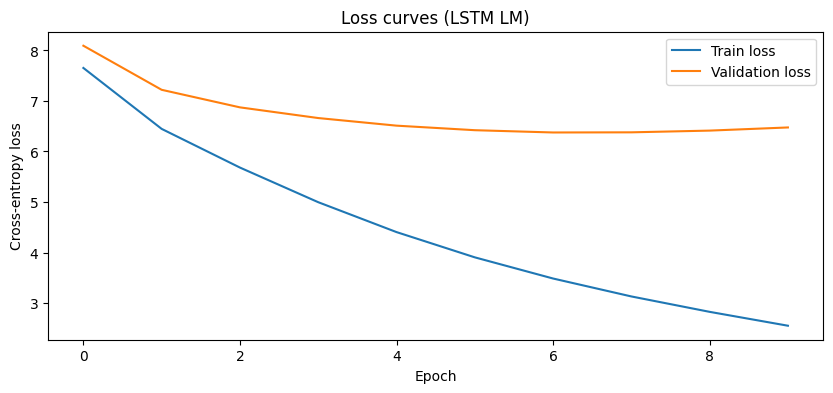

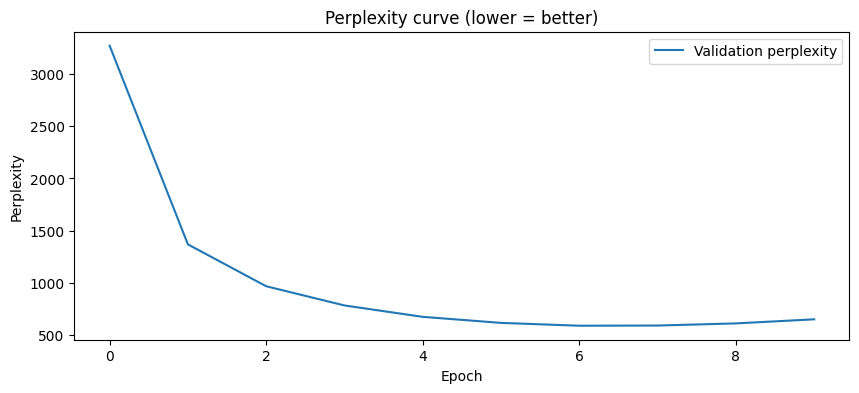

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["val_loss"], label="Validation loss")
plt.title("Loss curves (LSTM LM)")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history["ppl"], label="Validation perplexity")
plt.title("Perplexity curve (lower = better)")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.legend()
plt.show()


## Evaluation

In [67]:
# test loop
with torch.no_grad():
    model.eval()
    test_loss = 0.0
    count = 0

    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits.view(-1, vocab_size), y.view(-1))
        test_loss += loss.item()
        count += 1

    avg_test_loss = test_loss / max(count, 1)
    test_ppl = math.exp(avg_test_loss)

    print(f"Test loss={avg_test_loss:.4f} | Test perplexity={test_ppl:.2f}")

Test loss=6.6854 | Test perplexity=800.63


### Measure Perplexity